In [2]:
import pandas as pd

train = pd.read_csv("../data/processed/train.csv")
test = pd.read_csv("../data/processed/test.csv")

print("Training data shape:", train.shape)
print("Testing data shape:", test.shape)
train.head()

Training data shape: (190, 3)
Testing data shape: (48, 3)


,msg,cleaned_msg,status
0,Masroof hain? Jazz Auto Reply se bina call uth...,masroof jazz auto reply bina call uthae caller...,Genuine
1,"Government scheme: Sab betiyon ko 1000 milega,...",government scheme betiyon numtoken milega regi...,Scam
2,Mubarak ho Hina! Aap Meezan Bank lottery ke wi...,mubarak hina aap meezan bank lottery winner pr...,Scam
3,"Usman, ammi keh rahi hain ke ghar aatay huay d...",usman ammi keh ghar aatay huay doodh ana haan ...,Genuine
4,PTA Alert: Aap ka SIM 48 ghantay mein block ho...,pta alert aap sim numtoken ghantay block jayeg...,Scam


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(train["cleaned_msg"])
X_test = vectorizer.transform(test["cleaned_msg"])

y_train = train["status"]
y_test = test["status"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (190, 1603)
X_test shape: (48, 1603)


In [4]:
from sklearn.naive_bayes import MultinomialNB

# Model banana
nb_model = MultinomialNB()

# Model ko training data se seekhna (train karna)
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Test data pe predictions lena
y_pred = nb_model.predict(X_test)

# Accuracy check karna
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Detailed report (Precision, Recall, F1-score)
print("\nDetailed Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9791666666666666

Detailed Report:

              precision    recall  f1-score   support

     Genuine       0.96      1.00      0.98        26
        Scam       1.00      0.95      0.98        22

    accuracy                           0.98        48
   macro avg       0.98      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48

Confusion Matrix:

[[26  0]
 [ 1 21]]


In [6]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nDetailed Report:\n")
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.9791666666666666

Detailed Report:

              precision    recall  f1-score   support

     Genuine       0.96      1.00      0.98        26
        Scam       1.00      0.95      0.98        22

    accuracy                           0.98        48
   macro avg       0.98      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48

Confusion Matrix:

[[26  0]
 [ 1 21]]


In [6]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nDetailed Report:\n")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9791666666666666

Detailed Report:

              precision    recall  f1-score   support

     Genuine       0.96      1.00      0.98        26
        Scam       1.00      0.95      0.98        22

    accuracy                           0.98        48
   macro avg       0.98      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48

Confusion Matrix:

[[26  0]
 [ 1 21]]


In [8]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_lr)
    ]
})

print(comparison)

                 Model  Accuracy
0          Naive Bayes  0.979167
1                  SVM  0.979167
2  Logistic Regression  0.979167


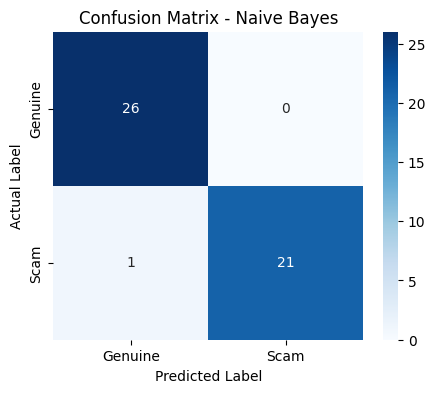

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Naive Bayes ka confusion matrix banate hain (best/representative model ke tor pe)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine', 'Scam'],
            yticklabels=['Genuine', 'Scam'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Naive Bayes')
plt.savefig("../outputs/confusion_matrix_nb.png", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
import pickle

# Model save karna
with open("../outputs/nb_model.pkl", "wb") as f:
    pickle.dump(nb_model, f)

# Vectorizer save karna (jo humne khud train data pe fit kiya tha)
with open("../outputs/my_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Model aur vectorizer save ho gaye!")

Model aur vectorizer save ho gaye!


In [11]:
import pickle

with open("../outputs/nb_model.pkl", "wb") as f:
    pickle.dump(nb_model, f)
with open("../outputs/svm_model.pkl", "wb") as f:
    pickle.dump(svm_model, f)
with open("../outputs/lr_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)
with open("../outputs/my_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Teeno models save ho gaye!")

Teeno models save ho gaye!
